Analyzing MCMC samples to characterize the system under test through multiple analyses

1) Mean variance plot over all the samples

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
file_path = "500000iteration_episode6_mcmc.npz"
data = np.load(file_path)

In [9]:
# NPZ file is a zipped file of multiple numpy arrays. Each array stores a different variable (winds applied, episode length, etc)
for key in data.files:
    print(key, data[key].shape, data[key].dtype) # Print the shape of each array

winds (100001, 350) float32
episode_lengths (100001,) int32
victim_failed (100001,) bool
failure_steps (100001,) int32
max_wind () float32
wind_sigma () float32
horizon () int32
chain (100001, 350) float32
log_scores (100001,) float64
accepted (100000,) bool
proposal_failed (100000,) bool
proposal_failure_steps (100000,) int32
proposal_out_of_bounds (100000,) bool
proposal_log_scores (100000,) float64
acceptance_probabilities (100000,) float64
initial_trace (350,) float32
source_episode_index () int32
source_episode_length () int32
source_failure_step () int32
source_horizon () int32
source_wind_sigma () float32
natural_wind_sigma () float64
env_seed () int64
proposal_sigma () float64
proposal_mode () <U3
block_size () int32
mcmc_seed () int64
iterations () int32


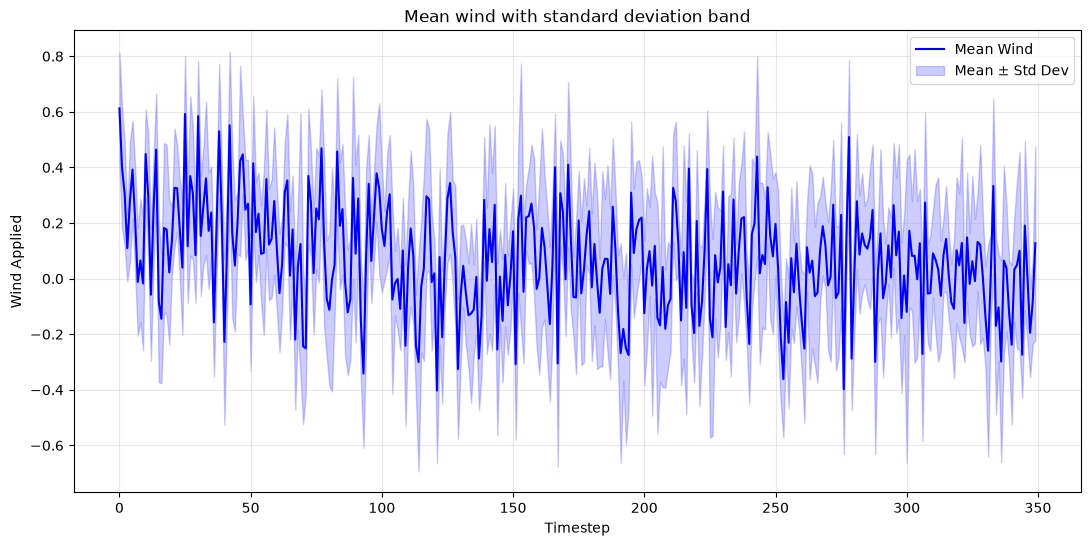

In [ ]:
chain = data['chain']
failure_steps = data['failure_steps']

num_timesteps = np.arange(chain.shape[1]) # 350 timesteps in each failure trace

active_wind = chain.copy()
for i in range(chain.shape[0]): # loop through each trace
    failure_step = failure_steps[i]
    # active_wind[i, failure_step:] = np.nan #set all wind values after the trace failed to NAN


mean_wind = np.nanmean(active_wind, axis=0)
variance = np.nanvar(active_wind, axis=0)
std_wind = np.nanstd(active_wind, axis=0)

# MEAN WIND WITH STANDARD DEVIATION BAND PLOT

# Creates empty canvas of X inches wide and Y inches tall
plt.figure(figsize=(13, 6)) 

# Plots
plt.plot(num_timesteps, mean_wind, label="Mean Wind", color="blue")
plt.fill_between(num_timesteps, mean_wind - std_wind, mean_wind + std_wind, color="blue", alpha=0.2, label="Mean ± Std Dev") # Shade in uncertainty region (mean +- std)

# Graphing conventions
plt.xlabel("Timestep")
plt.ylabel("Wind Applied")
plt.title("Mean wind with standard deviation band")
plt.legend()
plt.grid(alpha=0.3)

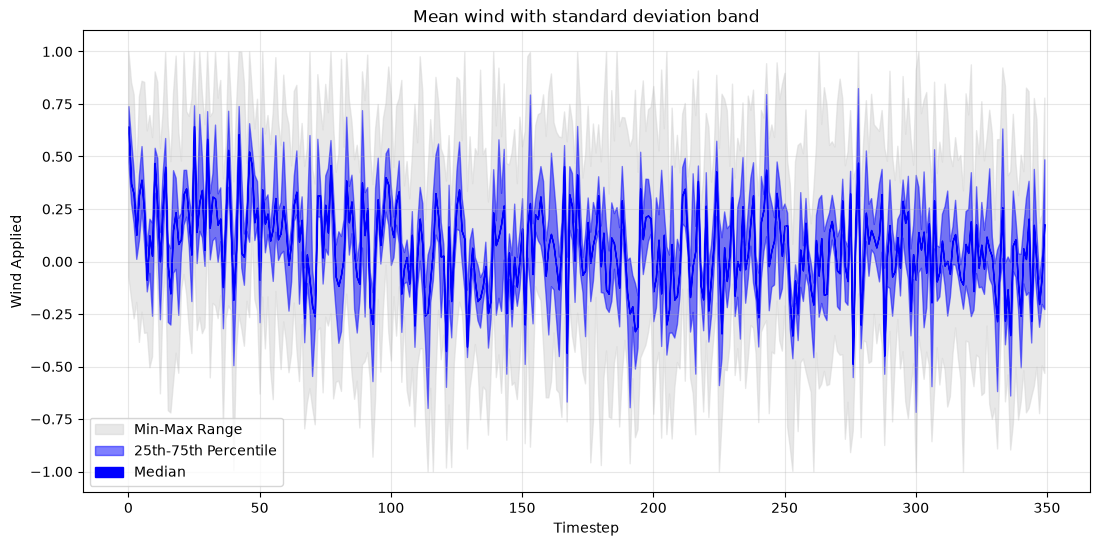

In [104]:
chain = data['chain']
failure_steps = data['failure_steps']

num_timesteps = np.arange(chain.shape[1]) # 350 timesteps in each failure trace

active_wind = chain.copy()

q = np.nanquantile(active_wind, [0.0, 0.25, 0.5, 0.75, 1.0], axis=0) # Calculate the 25th, 50th (median), and 75th percentiles of the wind data across all traces

# MEAN WIND WITH STANDARD DEVIATION BAND PLOT

# Creates empty canvas of X inches wide and Y inches tall
plt.figure(figsize=(13, 6)) 

# Plots
plt.fill_between(num_timesteps, q[0], q[4], color="lightgray", alpha=0.5, label="Min-Max Range") # Shade in uncertainty region (min-max range)
plt.fill_between(num_timesteps, q[1], q[3], color="blue", alpha=0.5, label="25th-75th Percentile") # Shade in uncertainty region (25th-75th percentile)
plt.fill_between(num_timesteps, q[2], q[2], color="blue", alpha=1.0, label="Median") # Shade in uncertainty region (median)

# Graphing conventions
plt.xlabel("Timestep")
plt.ylabel("Wind Applied")
plt.title("Mean wind with standard deviation band")
plt.legend()
plt.grid(alpha=0.3)

The mean wind starts positive (right direction), then drops more towards negative and starts to keep changing direction later in the episode, so it shows that both wind directions can cause failure. 

The std band is wide everywhere, suggesting that many different wind values can produce failure. 

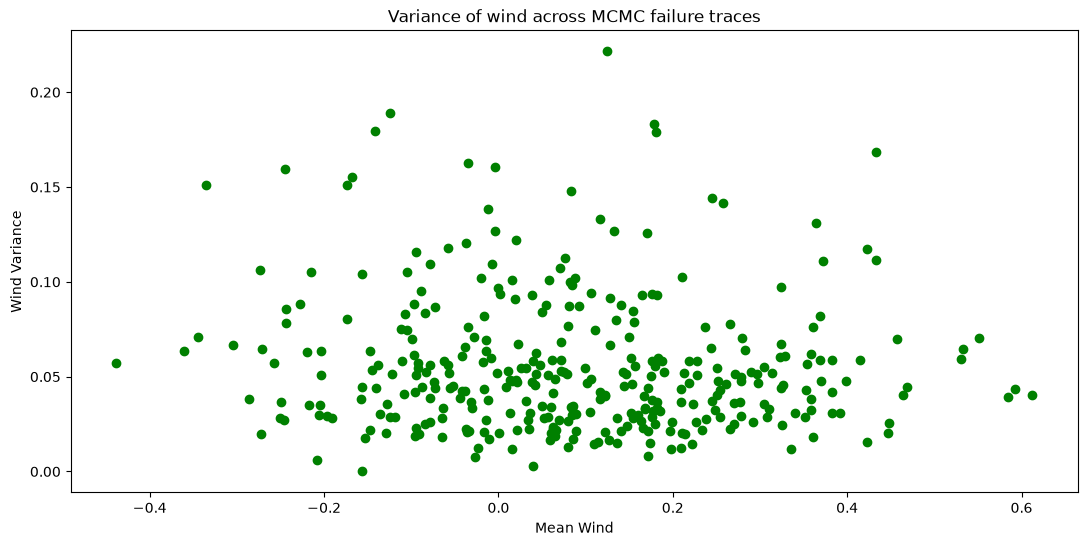

In [38]:
# MEAN-VARIANCE SCATTER PLOT

plt.figure(figsize=(13, 6))

plt.scatter(mean_wind, variance, label="Mean vs Variance", color="green")
plt.xlabel("Mean Wind")
plt.ylabel("Wind Variance")
plt.title("Variance of wind across MCMC failure traces")
plt.show()

First, most timesteps have positive wind, so wind in the right direction seems more useful for failures. 
There isn't any trend really between larger winds and larger variance. 

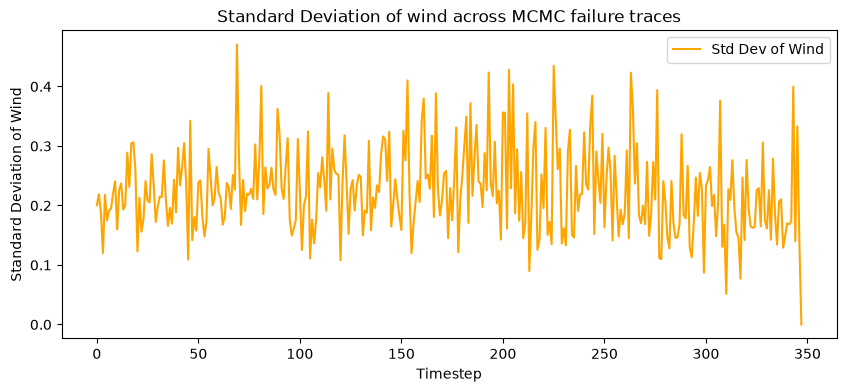

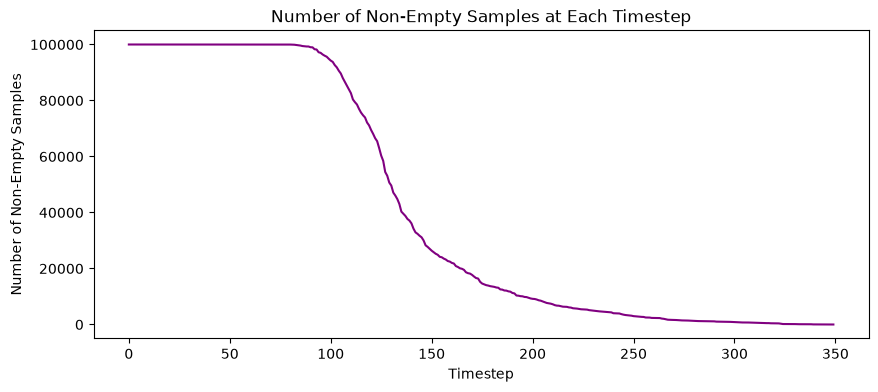

In [43]:
# STD vs Timestep Plot
plt.figure(figsize=(10, 4))
plt.plot(num_timesteps, std_wind, label="Std Dev of Wind", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Standard Deviation of Wind")
plt.title("Standard Deviation of wind across MCMC failure traces")
plt.legend()
plt.show()


# Plot % of non-empty samples at each timestep to validate the STD value by seeing if there's enough samples at each timestep
sample_count = np.sum(~np.isnan(active_wind), axis=0) 
sample_fraction = sample_count / chain.shape[0]

plt.figure(figsize=(10, 4))
plt.plot(num_timesteps, sample_count, label="Number of Non-Empty Samples", color="purple")
plt.xlabel("Timestep")
plt.ylabel("Number of Non-Empty Samples")
plt.title("Number of Non-Empty Samples at Each Timestep")
plt.show()


Timesteps 100-150 form the main failure window. The STD is super variable so the system reaches failure through different wind patterns, but usually around the same time. 

C:\Users\sghorai\AppData\Local\Temp\1\ipykernel_21904\3271503684.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


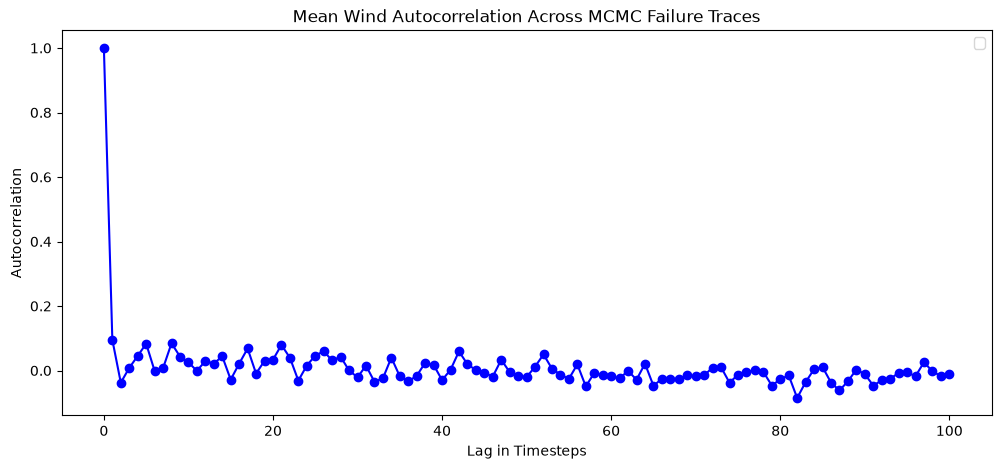

C:\Users\sghorai\AppData\Local\Temp\1\ipykernel_21904\3271503684.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


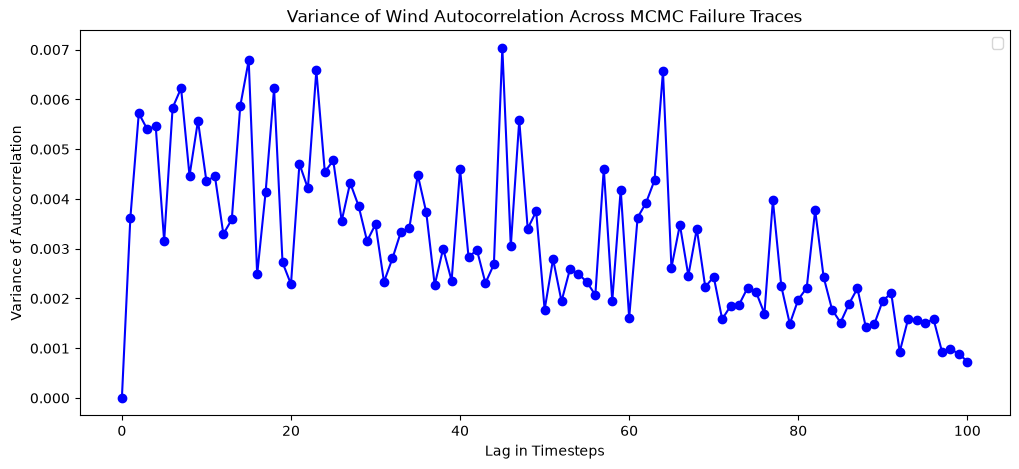

In [83]:
# AUTOCORRELATION ANALYSIS

# Subtract the mean from each trace to center the data around zero. If everything is positive, it might look more correlated just because its positive. 
# This process of "demeaning" is common in time series analysis to remove bias and focus on the fluctuations around the mean.

trace_means = np.nanmean(active_wind, axis=1, keepdims=True) # mean of each trace (like going the columns for each row)
demeaned_traces = active_wind - trace_means # subtract the mean of each trace

max_lag = 100
lags = np.arange(max_lag + 1) # [0, 1, 2, ..., 100]

# row for every trace, column for every lag amount
# you test each trace against the lag for itself and doing it for 100 lags, and then do the same thing for every trace
autocorrelations = np.full((chain.shape[0], max_lag + 1), np.nan, dtype=np.float32) 

for i in range(chain.shape[0]):
    failure_step = failure_steps[i] # get failure step for that trace 
    trace_alive = demeaned_traces[i, :failure_step] # only consider the part of the trace before it failed

    full_correlation = np.correlate(trace_alive, trace_alive, mode='full') 

    # np.correlate does negative lags up to 100 and then positive lags up to 100 since its supposed to be for different signals
    # since its the same signal, the negative lags are redundant, so only include the positive ones

    positive_correlation = full_correlation[len(trace_alive) - 1 :] # take the positive half
    if positive_correlation[0] == 0:
        continue # Avoid division by zero if the trace is all zeros after demeaning

    normalized_correlation = positive_correlation / positive_correlation[0] #normalize it so that the autocorrelation at lag 0 is 1

    num_lags = min(max_lag + 1, len(normalized_correlation)) # only take as many lags as are available in the trac
    # save lags for that trace
    autocorrelations[i, :num_lags] = normalized_correlation[:num_lags]


mean_autocorrelation = np.nanmean(autocorrelations, axis=0) # mean across all traces for each lag
var_autocorrelation = np.nanvar(autocorrelations, axis=0) # variance across all traces for each lag

plt.figure(figsize=(12, 5))
plt.plot(lags, mean_autocorrelation, marker='o', linestyle='-', color='blue')
plt.xlabel("Lag in Timesteps")
plt.ylabel("Autocorrelation")
plt.title("Mean Wind Autocorrelation Across MCMC Failure Traces")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(lags, var_autocorrelation, marker='o', linestyle='-', color='blue')
plt.xlabel("Lag in Timesteps")
plt.ylabel("Variance of Autocorrelation")
plt.title("Variance of Wind Autocorrelation Across MCMC Failure Traces")
plt.legend()
plt.show()
    


Not much here, but lot of variance (relatively) around lag of 40

C:\Users\sghorai\AppData\Local\Temp\1\ipykernel_21904\2829384117.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


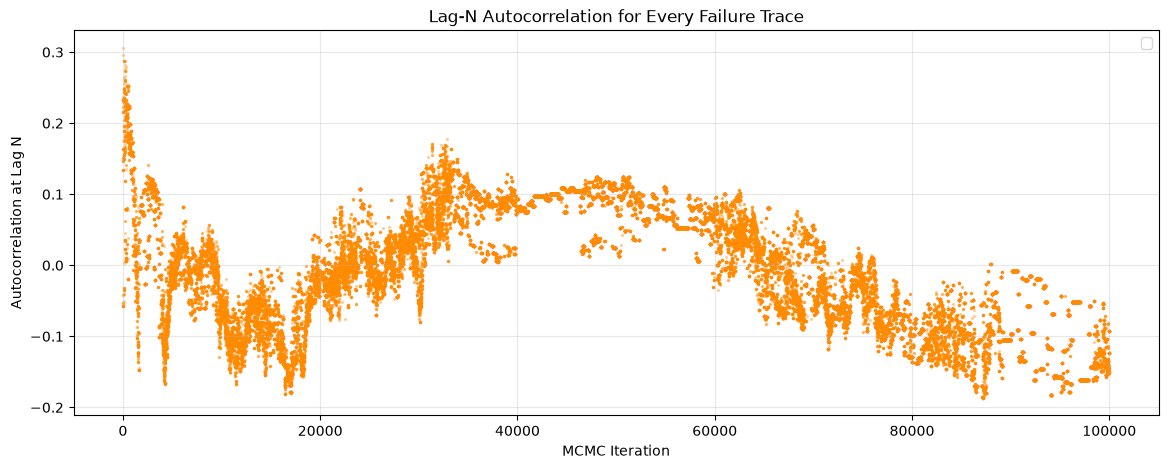

C:\Users\sghorai\AppData\Local\Temp\1\ipykernel_21904\2829384117.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


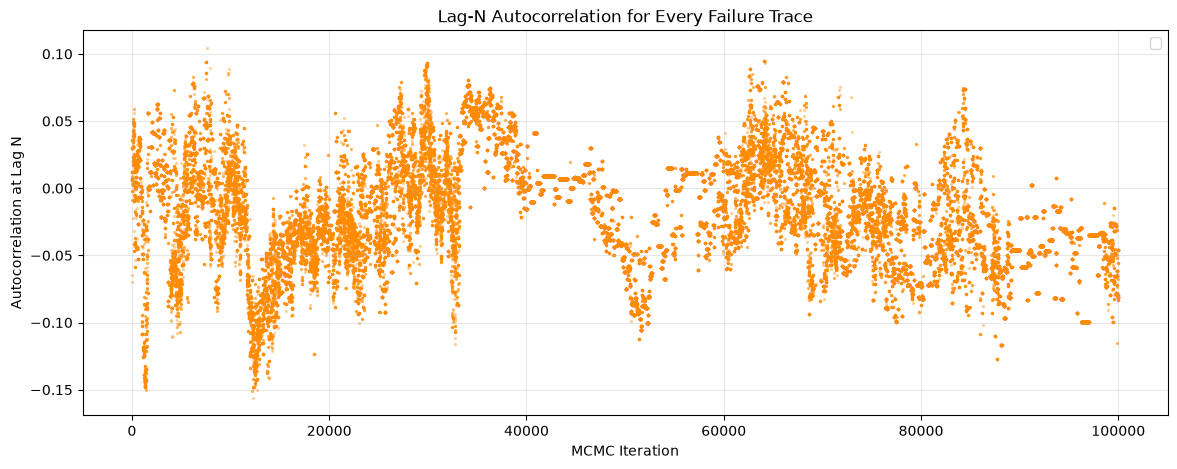

In [85]:
lag_to_analyze = 45
lag40_values = autocorrelations[:, lag_to_analyze]  # Extract autocorrelation values at lag N for all traces
trace_indices = np.arange(chain.shape[0])  # Indices for each trace
valid = ~np.isnan(lag40_values)

plt.figure(figsize=(14, 5))
plt.scatter(
    trace_indices[valid],
    lag40_values[valid],
    s=2,
    alpha=0.3,
    color="darkorange"
)
plt.xlabel("MCMC Iteration")
plt.ylabel("Autocorrelation at Lag N")
plt.title("Lag-N Autocorrelation for Every Failure Trace")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

lag_to_analyze = 60
lag40_values = autocorrelations[:, lag_to_analyze]  # Extract autocorrelation values at lag N for all traces
trace_indices = np.arange(chain.shape[0])  # Indices for each trace
valid = ~np.isnan(lag40_values)

plt.figure(figsize=(14, 5))
plt.scatter(
    trace_indices[valid],
    lag40_values[valid],
    s=2,
    alpha=0.3,
    color="darkorange"
)
plt.xlabel("MCMC Iteration")
plt.ylabel("Autocorrelation at Lag N")
plt.title("Lag-N Autocorrelation for Every Failure Trace")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


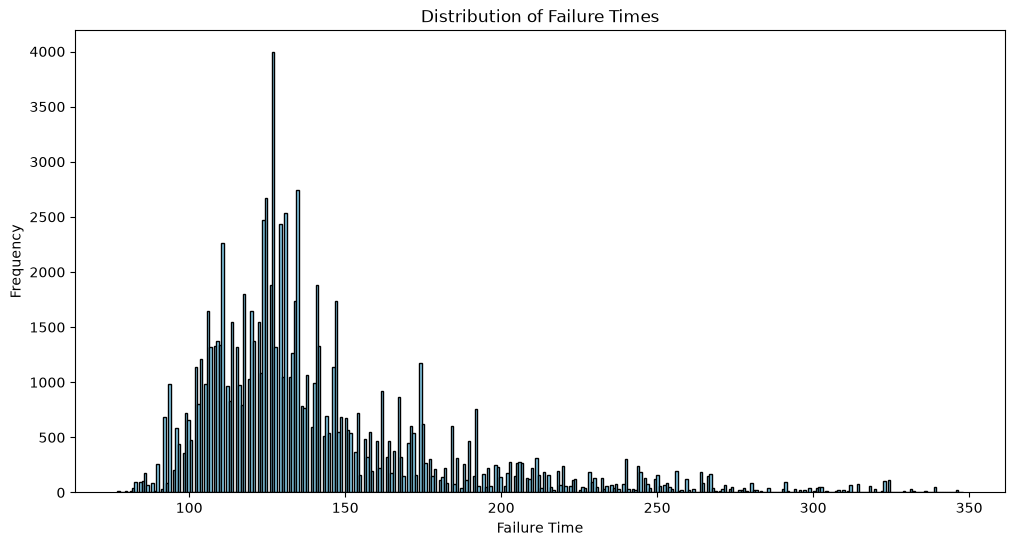

In [75]:
# Histogram of failure times

plt.figure(figsize=(12, 6))
plt.hist(failure_steps, bins=350, color='skyblue', edgecolor='black')
plt.xlabel("Failure Time")
plt.ylabel("Frequency")
plt.title("Distribution of Failure Times")
plt.show()

Validates that most traces fail between 100 and 150 timesteps

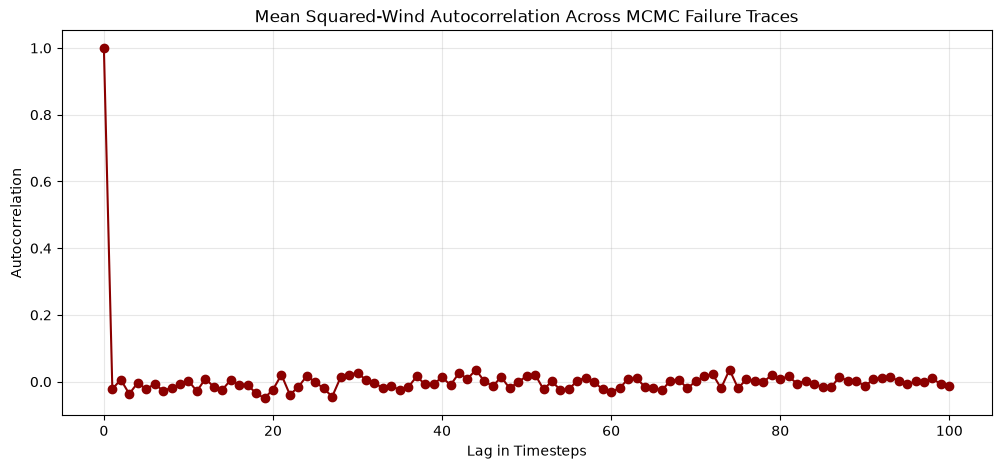

In [79]:
# Autocorrelation of squared wind
# Try to see if signal has weak directional correlation but strong magnitude correlation


squared_autocorrelations = np.full_like(
    autocorrelations,
    np.nan
)
for i in range(chain.shape[0]):
    failure_step = failure_steps[i]

    # Use the demeaned wind before failure
    trace_alive = demeaned_traces[i, :failure_step]

    # Square it so positive and negative wind both represent magnitude
    squared_trace = trace_alive ** 2

    # Squaring creates a positive mean, so center it again
    squared_trace = squared_trace - np.mean(squared_trace)

    full_correlation = np.correlate(squared_trace, squared_trace, mode="full")

    # Keep lag zero and positive lags
    positive_correlation = full_correlation[
        len(squared_trace) - 1:
    ]

    # Avoid division by zero if squared magnitude never changes
    if positive_correlation[0] == 0:
        continue

    normalized_correlation = (
        positive_correlation / positive_correlation[0]
    )

    num_lags = min(
        max_lag + 1,
        len(normalized_correlation)
    )

    squared_autocorrelations[i, :num_lags] = (
        normalized_correlation[:num_lags]
    )


# Mean and variance across traces at every lag
mean_squared_autocorrelation = np.nanmean(
    squared_autocorrelations,
    axis=0
)


# Mean squared-wind autocorrelation plot
plt.figure(figsize=(12, 5))
plt.plot(lags,mean_squared_autocorrelation,marker="o",linestyle="-",color="darkred")
plt.xlabel("Lag in Timesteps")
plt.ylabel("Autocorrelation")
plt.title("Mean Squared-Wind Autocorrelation Across MCMC Failure Traces")
plt.grid(alpha=0.3)
plt.show()


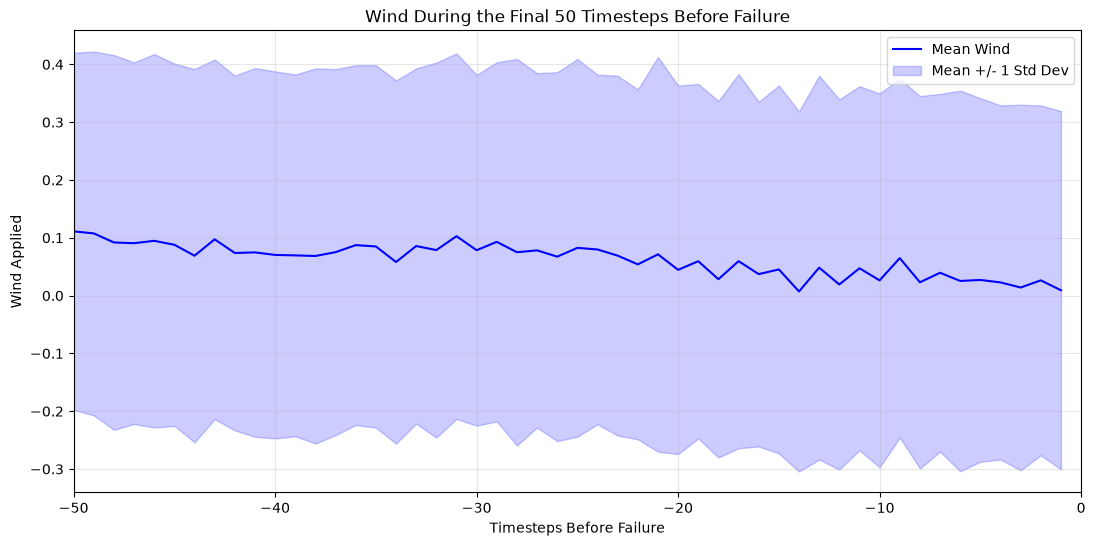

In [80]:
# FAILURE-ALIGNED EVENT STUDY

# Examine the final 50 applied winds before each failure
window = 50

# Row = one failure trace
# Column = position relative to failure
failure_aligned_wind = np.full(
    (chain.shape[0], window),
    np.nan,
    dtype=np.float32
)

for i in range(chain.shape[0]):
    failure_step = failure_steps[i]

    # Start 50 steps before failure, or at zero for a short trace
    start = max(0, failure_step - window)

    # Extract the winds applied immediately before failure
    wind_before_failure = chain[i, start:failure_step]

    # Right-align so the final column is always one step before failure
    failure_aligned_wind[i, -len(wind_before_failure):] = wind_before_failure


# Calculate statistics at each position before failure
failure_aligned_mean = np.nanmean(
    failure_aligned_wind,
    axis=0
)

failure_aligned_std = np.nanstd(
    failure_aligned_wind,
    axis=0
)

# -50, -49, ..., -2, -1
time_before_failure = np.arange(-window, 0)


# Plot mean wind and standard-deviation envelope
plt.figure(figsize=(13, 6))

plt.plot(
    time_before_failure,
    failure_aligned_mean,
    color="blue",
    label="Mean Wind"
)

plt.fill_between(
    time_before_failure,
    failure_aligned_mean - failure_aligned_std,
    failure_aligned_mean + failure_aligned_std,
    color="blue",
    alpha=0.2,
    label="Mean +/- 1 Std Dev"
)


plt.xlabel("Timesteps Before Failure")
plt.ylabel("Wind Applied")
plt.title("Wind During the Final 50 Timesteps Before Failure")
plt.xlim(-window, 0)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Tried to see if there was a pattern between traces for the amount of wind applied right before failures. So this takes the last 50 timesteps before a trace fails so all the traces are aligned by their last 50 steps before failure and plots the applied wind. There doesn't seem to be any relationship though, as standard deviation always remains high. 